# BTC/USDT · PPO 课程训练 stage3（1 小时 K 线）

基于《PPO 训练优化：观察归一化 & 奖励整形》P0–P10 改进与课程学习方案 §5.2 / §14.5。

**目标**：在 1 小时 K 线 上训练 PPO，作为下游更高频阶段的策略热启动来源。
**热启动**：从 `BTCUSDT__ppo_stage2_4h` 加载策略权重 → `warm_start_policy()`。

| 编号 | 改进 | 实现位置 |
|------|------|---------|
| P0   | 观察分组归一化（÷last_close / ÷100 / OBV pct） | `ppo_shared.CryptoPPOEnv._get_obs` |
| P0b  | VecNormalize 在线 running stats | 训练配置 |
| P1   | 即时交易惩罚 `trade_penalty_coef` | `CryptoPPOEnv.step` |
| P5   | 动作惯性惩罚（持仓状态翻转 + pos_history buffer） | `CryptoPPOEnv` |
| P8   | 对数收益率 + 非对称风险惩罚 | `CryptoPPOEnv.step` |
| P9   | 1D-CNN + AdaptiveAvgPool（跨阶段权重迁移）| `ppo_shared.TradingCNN` |
| P10  | SubprocVecEnv + `random_start=True` | 训练配置 |


**数据来源**：PostgreSQL (OHLCV, 1m → resample 至目标 TF)


## 1. 配置

In [1]:
# ── 数据参数 ────────────────────────────────────────────────────
SYMBOL      = "BTC/USDT"
START_DATE  = "2021-01-01 00:00:00"   # doc §12.4 stage3 起点
END_DATE    = "2026-04-13 00:00:00"
TIMEZONE    = "Asia/Shanghai"
DB_TABLE    = "public.crypto_kline_binance"
ONLY_CLOSED = True

TF_RESAMPLE = "1H"

# ── 环境参数（stage3 / 1h）─────────────────
WINDOW_SIZE         = 120
INITIAL_BALANCE     = 10_000.0
COMMISSION          = 0.001     # P3: stage3 模拟点差/滑点
TRADE_PENALTY_COEF  = 1.0        # P1: β
ACTION_INERTIA_COEF = 0.001      # P5: λ
RISK_AVERSION_COEF  = 2.0        # P8: α

TRAIN_RATIO = 0.8

# ── 并发参数（P10）──────────────────────────────────────────────
N_ENVS = 8

# ── PPO 超参数（doc §12.4 stage3）─────────────────────
TOTAL_TIMESTEPS = 1_500_000      # 上限预算；EvalCallback 早停
PPO_KWARGS = dict(
    learning_rate = 1.5e-04,
    n_steps       = 512,
    batch_size    = 512,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.15,
    ent_coef      = 0.005,
    vf_coef       = 0.5,
    max_grad_norm = 0.5,
)

# ── CNN + Policy head（P9）─────────────────────────────────────
FEATURES_DIM = 256
NET_ARCH     = dict(pi=[128, 64], vf=[128, 64])

# ── 课程热启动 ─────────────────────────────────────────────────
WARM_START_FROM = "BTCUSDT__ppo_stage2_4h"   # 上一阶段 RUN_NAME；从该目录的 best_model 热启动

# ── 输出路径 ────────────────────────────────────────────────────
RUN_NAME  = "BTCUSDT__ppo_stage3_1h"
MODEL_DIR = "../models/saved"
LOG_DIR   = "../models/logs"


## 2. 数据加载

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecNormalize

matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

from utils.db import read_ohlcv
from agents.ppo_shared import (
    add_indicators,
    add_multi_timeframe_indicators,
    resample_ohlcv,
    CryptoPPOEnv,
    TradingCNN,
    warm_start_policy,
    FEATURE_COLS_BASE,
    FEATURE_COLS_MTF,
    STAGE3_TO_STAGE4_CHANNEL_MAP,
)

# ── OHLCV 加载（1m 原始） ──────────────────────────────────────
tz = TIMEZONE
start_utc = pd.Timestamp(START_DATE, tz=tz).tz_convert("UTC").isoformat()
end_utc   = pd.Timestamp(END_DATE,   tz=tz).tz_convert("UTC").isoformat()

df_raw = read_ohlcv(SYMBOL, start=start_utc, end=end_utc,
                    table=DB_TABLE, only_closed=ONLY_CLOSED)
ts = df_raw["timestamp"]
if ts.dt.tz is None:
    ts = ts.dt.tz_localize("UTC")
df_raw["timestamp"] = ts.dt.tz_convert(tz)

print(f"原始 1m 行数 : {len(df_raw):,}")
print(f"时间范围     : {df_raw['timestamp'].min()} → {df_raw['timestamp'].max()}")
df_raw.head(3)


原始 1m 行数 : 2,774,767
时间范围     : 2021-01-01 08:00:00+08:00 → 2026-04-12 23:59:00+08:00


,timestamp,open,high,low,close,volume
0,2021-01-01 08:00:00+08:00,28923.63,28961.66,28913.12,28961.66,27.457032
1,2021-01-01 08:01:00+08:00,28961.67,29017.50,28961.01,29009.91,58.477501
2,2021-01-01 08:02:00+08:00,29009.54,29016.71,28973.58,28989.30,42.470329


## 3. 特征工程

In [3]:
# ── 1m → 1h resample，再计算基础指标 ───────────
df_tf = resample_ohlcv(df_raw, TF_RESAMPLE)
df_full = add_indicators(df_tf.set_index("timestamp")).dropna().reset_index()

FEATURE_COLS = FEATURE_COLS_BASE
print(f"resample 后行数 : {len(df_full):,}  ({TF_RESAMPLE})")
print(f"特征列数         : {len(FEATURE_COLS)}  (基础)")
print(FEATURE_COLS)
df_full.head(3)


/home/davidlyu/projects/GinkgoBrain/notebooks/../agents/ppo_shared.py:93: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  out = df.resample(timeframe, closed="left", label="left").agg({


resample 后行数 : 46,217  (1H)
特征列数         : 16  (基础)
['open', 'high', 'low', 'close', 'volume', 'ema_9', 'ema_21', 'macd', 'macd_signal', 'rsi', 'stoch_k', 'stoch_d', 'bb_upper', 'bb_lower', 'atr', 'obv']


,timestamp,open,high,low,close,volume,ema_9,ema_21,macd,macd_signal,rsi,stoch_k,stoch_d,bb_upper,bb_lower,atr,obv
0,2021-01-02 17:00:00+08:00,29844.52,29899.00,29578.05,29612.87,3188.497375,29570.054768,29414.897973,143.126341,98.415524,59.335334,71.910311,88.513491,29806.503175,28897.757825,265.266324,-2237.862524
1,2021-01-02 18:00:00+08:00,29612.88,29829.00,29473.91,29680.99,2315.182337,29592.241814,29439.088158,145.477674,107.827954,61.347500,77.111090,82.848852,29845.938277,28893.637723,271.682301,77.319813
2,2021-01-02 19:00:00+08:00,29679.51,29780.53,29622.79,29755.00,1365.036655,29624.793452,29467.807416,151.565952,116.575554,63.462846,84.881414,77.967605,29894.721758,28901.487242,263.543565,1442.356468


## 4. 数据集划分（时间序列 8:2）

In [4]:
feat_matrix = df_full[FEATURE_COLS].values.astype(np.float32)
timestamps  = df_full["timestamp"].reset_index(drop=True)

n_total = len(feat_matrix)
n_train = int(n_total * TRAIN_RATIO)

train_feat, eval_feat = feat_matrix[:n_train], feat_matrix[n_train:]
train_ts,   eval_ts   = timestamps.iloc[:n_train], timestamps.iloc[n_train:]

print(f"总步数  : {n_total:,}")
print(f"训练集  : {n_train:,} 步  ({train_ts.iloc[0]}  →  {train_ts.iloc[-1]})")
print(f"验证集  : {n_total - n_train:,} 步  ({eval_ts.iloc[0]}  →  {eval_ts.iloc[-1]})")

assert n_train > WINDOW_SIZE + 100 and (n_total - n_train) > WINDOW_SIZE + 100, \
    "数据集太短，请缩小 WINDOW_SIZE 或扩大日期范围"
print("✓ 数据集检查通过")


总步数  : 46,217
训练集  : 36,973 步  (2021-01-02 17:00:00+08:00  →  2025-03-23 19:00:00+08:00)
验证集  : 9,244 步  (2025-03-23 20:00:00+08:00  →  2026-04-12 23:00:00+08:00)
✓ 数据集检查通过


## 5. 训练

- **`SubprocVecEnv`**：多进程并行采集 rollout（P10）。
- **`VecNormalize(norm_obs=True, norm_reward=False)`**：在 P0 语义归一化之上叠加在线 running stats（P0b）。
- **`TradingCNN` + AdaptiveAvgPool**：让 Linear 层维度与 `window_size` 解耦，是跨阶段权重迁移的关键。
- **`EvalCallback`**：周期评估并保存 `best_model.zip`，作为下一阶段的热启动来源。

In [5]:
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)
Path(LOG_DIR).mkdir(parents=True, exist_ok=True)


def make_train_env():
    env = CryptoPPOEnv(
        train_feat, FEATURE_COLS,
        window_size         = WINDOW_SIZE,
        initial_balance     = INITIAL_BALANCE,
        commission          = COMMISSION,
        trade_penalty_coef  = TRADE_PENALTY_COEF,
        action_inertia_coef = ACTION_INERTIA_COEF,
        risk_aversion_coef  = RISK_AVERSION_COEF,
        random_start        = True,        # P10
    )
    return Monitor(env)


def make_eval_env():
    env = CryptoPPOEnv(
        eval_feat, FEATURE_COLS,
        window_size         = WINDOW_SIZE,
        initial_balance     = INITIAL_BALANCE,
        commission          = COMMISSION,
        trade_penalty_coef  = TRADE_PENALTY_COEF,
        action_inertia_coef = ACTION_INERTIA_COEF,
        risk_aversion_coef  = RISK_AVERSION_COEF,
        random_start        = False,       # eval 固定起点
    )
    return Monitor(env)


# ── 训练 venv：SubprocVecEnv + VecNormalize ────────────────────
train_vec = SubprocVecEnv([make_train_env] * N_ENVS, start_method="fork")
train_vec = VecNormalize(
    train_vec,
    norm_obs    = True,
    norm_reward = False,                    # 保持 P1/P5/P8 精确标定
    clip_obs    = 10.0,
    gamma       = PPO_KWARGS["gamma"],
)

# ── eval venv：冻结 stats ──────────────────────────────────────
eval_vec = DummyVecEnv([make_eval_env])
eval_vec = VecNormalize(
    eval_vec,
    norm_obs    = True,
    norm_reward = False,
    clip_obs    = 10.0,
    training    = False,
    gamma       = PPO_KWARGS["gamma"],
)

callbacks = [
    EvalCallback(
        eval_vec,
        best_model_save_path = f"{MODEL_DIR}/{RUN_NAME}",
        log_path             = f"{LOG_DIR}/{RUN_NAME}",
        eval_freq            = 20_000,
        n_eval_episodes      = 1,
        deterministic        = True,
        render               = False,
        verbose              = 1,
    ),
    CheckpointCallback(
        save_freq   = 100_000,
        save_path   = f"{MODEL_DIR}/{RUN_NAME}/checkpoints",
        name_prefix = RUN_NAME,
    ),
]

policy_kwargs = dict(
    features_extractor_class  = TradingCNN,
    features_extractor_kwargs = dict(features_dim=FEATURES_DIM),
    net_arch                  = NET_ARCH,
)

model = PPO(
    "MlpPolicy",
    train_vec,
    device          = "auto",
    tensorboard_log = LOG_DIR,
    policy_kwargs   = policy_kwargs,
    verbose         = 1,
    **PPO_KWARGS,
)

print(f"观测形状   : {model.observation_space.shape}")
print(f"并行环境   : {N_ENVS}  (每次 update = {N_ENVS * PPO_KWARGS['n_steps']:,} 步)")
print(f"特征提取器 : TradingCNN  (features_dim={FEATURES_DIM}, AdaptiveAvgPool 输出 {TradingCNN.POOL_SIZE})")
print(f"Policy 头  : pi={NET_ARCH['pi']}, vf={NET_ARCH['vf']}")
print(f"训练步数   : {TOTAL_TIMESTEPS:,}  (上限；EvalCallback 早停)")
print(f"TensorBoard: tensorboard --logdir {LOG_DIR}")


Using cuda device
观测形状   : (120, 18)
并行环境   : 8  (每次 update = 4,096 步)
特征提取器 : TradingCNN  (features_dim=256, AdaptiveAvgPool 输出 8)
Policy 头  : pi=[128, 64], vf=[128, 64]
训练步数   : 1,500,000  (上限；EvalCallback 早停)
TensorBoard: tensorboard --logdir ../models/logs


/home/davidlyu/projects/GinkgoBrain/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


## 5b. 课程热启动（从 `BTCUSDT__ppo_stage2_4h`）

In [6]:
# ── 课程热启动（doc §5.2 / §14.5） ─────────────────────────────
# Stage2 → Stage3：观测通道数相同（18），所有同形状参数直接复制；AdaptiveAvgPool 让 Linear 层维度与 window_size 解耦，因此 window 从 48 → 120 也不阻塞权重迁移。
prev_best = f"{MODEL_DIR}/{WARM_START_FROM}/best_model.zip"

if not Path(prev_best).exists():
    raise FileNotFoundError(
        f"未找到上一阶段最佳模型：{prev_best}\n"
        f"请先训练 stage{3-1} 并产出 best_model.zip"
    )

report = warm_start_policy(model, prev_best, in_channel_mapping=None)

print(f"热启动来源 : {prev_best}")
print(f"  ✓ 同形状参数迁移   : {len(report['moved'])} 项")
print(f"  ✓ 通道选择性扩展   : {len(report['expanded'])} 项 ({report['expanded'] or '—'})")
print(f"  ⊘ 跳过（形状不兼容）: {len(report['skipped'])} 项")
for name, why in report['skipped'][:5]:
    print(f"      · {name}  →  {why}")


热启动来源 : ../models/saved/BTCUSDT__ppo_stage2_4h/best_model.zip
  ✓ 同形状参数迁移   : 36 项
  ✓ 通道选择性扩展   : 0 项 (—)
  ⊘ 跳过（形状不兼容）: 0 项


## 6. 启动训练

In [7]:
model.learn(
    total_timesteps = TOTAL_TIMESTEPS,
    callback        = callbacks,
    tb_log_name     = RUN_NAME,
    progress_bar    = True,
)

# P0b §3.4.5：VecNormalize running stats 必须随模型权重一起保存
model.save(f"{MODEL_DIR}/{RUN_NAME}/final")
train_vec.save(f"{MODEL_DIR}/{RUN_NAME}/final_vecnorm.pkl")

print(f"模型   → {MODEL_DIR}/{RUN_NAME}/final.zip")
print(f"归一化 → {MODEL_DIR}/{RUN_NAME}/final_vecnorm.pkl")
print(f"最佳   → {MODEL_DIR}/{RUN_NAME}/best_model.zip   (供下一阶段热启动)")


Logging to ../models/logs/BTCUSDT__ppo_stage3_1h_1


Output()

-----------------------------
| time/              |      |
|    fps             | 1821 |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 4096 |
-----------------------------


------------------------------------------
| time/                   |              |
|    fps                  | 1603         |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0125389565 |
|    clip_fraction        | 0.171        |
|    clip_range           | 0.15         |
|    entropy_loss         | -0.451       |
|    explained_variance   | 0.395        |
|    learning_rate        | 0.00015      |
|    loss                 | -0.0407      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0217      |
|    value_loss           | 3.18e-05     |
------------------------------------------


-----------------------------------------
| time/                   |             |
|    fps                  | 1597        |
|    iterations           | 3           |
|    time_elapsed         | 7           |
|    total_timesteps      | 12288       |
| train/                  |             |
|    approx_kl            | 0.010305617 |
|    clip_fraction        | 0.138       |
|    clip_range           | 0.15        |
|    entropy_loss         | -0.439      |
|    explained_variance   | -0.358      |
|    learning_rate        | 0.00015     |
|    loss                 | -0.0266     |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0193     |
|    value_loss           | 1.95e-05    |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.75e+04    |
|    ep_rew_mean          | -0.0368     |
| time/                   |             |
|    fps                  | 1605        |
|    iterations           | 364         |
|    time_elapsed         | 928         |
|    total_timesteps      | 1490944     |
| train/                  |             |
|    approx_kl            | 0.023257965 |
|    clip_fraction        | 0.173       |
|    clip_range           | 0.15        |
|    entropy_loss         | -0.367      |
|    explained_variance   | -3.67       |
|    learning_rate        | 0.00015     |
|    loss                 | -0.0311     |
|    n_updates            | 3630        |
|    policy_gradient_loss | -0.0212     |
|    value_loss           | 1.72e-06    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.75e+04    |
|    ep_rew_mean          | -0.0368     |
| time/                   |             |
|    fps                  | 1606        |
|    iterations           | 365         |
|    time_elapsed         | 930         |
|    total_timesteps      | 1495040     |
| train/                  |             |
|    approx_kl            | 0.020946858 |
|    clip_fraction        | 0.157       |
|    clip_range           | 0.15        |
|    entropy_loss         | -0.355      |
|    explained_variance   | -4.51       |
|    learning_rate        | 0.00015     |
|    loss                 | -0.0411     |
|    n_updates            | 3640        |
|    policy_gradient_loss | -0.0223     |
|    value_loss           | 4.9e-07     |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.74e+04    |
|    ep_rew_mean          | -0.0364     |
| time/                   |             |
|    fps                  | 1608        |
|    iterations           | 366         |
|    time_elapsed         | 931         |
|    total_timesteps      | 1499136     |
| train/                  |             |
|    approx_kl            | 0.024816755 |
|    clip_fraction        | 0.174       |
|    clip_range           | 0.15        |
|    entropy_loss         | -0.368      |
|    explained_variance   | -3.45       |
|    learning_rate        | 0.00015     |
|    loss                 | -0.0276     |
|    n_updates            | 3650        |
|    policy_gradient_loss | -0.019      |
|    value_loss           | 1.04e-06    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.74e+04    |
|    ep_rew_mean          | -0.0364     |
| time/                   |             |
|    fps                  | 1610        |
|    iterations           | 367         |
|    time_elapsed         | 933         |
|    total_timesteps      | 1503232     |
| train/                  |             |
|    approx_kl            | 0.030680502 |
|    clip_fraction        | 0.162       |
|    clip_range           | 0.15        |
|    entropy_loss         | -0.34       |
|    explained_variance   | -6.54       |
|    learning_rate        | 0.00015     |
|    loss                 | -0.0335     |
|    n_updates            | 3660        |
|    policy_gradient_loss | -0.0197     |
|    value_loss           | 7.03e-07    |
-----------------------------------------


模型   → ../models/saved/BTCUSDT__ppo_stage3_1h/final.zip
归一化 → ../models/saved/BTCUSDT__ppo_stage3_1h/final_vecnorm.pkl
最佳   → ../models/saved/BTCUSDT__ppo_stage3_1h/best_model.zip   (供下一阶段热启动)


## 7. 回测评估

In [8]:
# ── 加载模型 + 训练时的 VecNormalize 统计量 ──────────────────
best_model_path = f"{MODEL_DIR}/{RUN_NAME}/best_model"
vecnorm_path    = f"{MODEL_DIR}/{RUN_NAME}/final_vecnorm.pkl"

# 提取 obs_rms（避免 DummyVecEnv 的 auto-reset 抹掉 portfolio_history）
_loader     = VecNormalize.load(vecnorm_path, DummyVecEnv([make_eval_env]))
_obs_mean   = _loader.obs_rms.mean.astype(np.float32)
_obs_var    = _loader.obs_rms.var.astype(np.float32)
_obs_clip   = float(_loader.clip_obs)
_loader.close()

def _apply_vecnorm(obs: np.ndarray) -> np.ndarray:
    return np.clip(
        (obs - _obs_mean) / np.sqrt(_obs_var + 1e-8),
        -_obs_clip, _obs_clip,
    ).astype(np.float32)

eval_model = PPO.load(best_model_path, device="auto")
print(f"加载模型   : {best_model_path}.zip")
print(f"加载归一化 : {vecnorm_path}")

# ── 单 env 确定性 rollout ──────────────────────────────────────
bt_env = CryptoPPOEnv(
    eval_feat, FEATURE_COLS,
    window_size         = WINDOW_SIZE,
    initial_balance     = INITIAL_BALANCE,
    commission          = COMMISSION,
    trade_penalty_coef  = TRADE_PENALTY_COEF,
    action_inertia_coef = ACTION_INERTIA_COEF,
    risk_aversion_coef  = RISK_AVERSION_COEF,
    random_start        = False,
)
obs, _ = bt_env.reset()
done = False
while not done:
    obs_n = _apply_vecnorm(obs)
    action, _ = eval_model.predict(obs_n, deterministic=True)
    obs, reward, done, truncated, info = bt_env.step(int(np.asarray(action).item()))

pv_curve    = np.array(bt_env.portfolio_history)
trades      = bt_env.trades
eval_close  = eval_feat[:, FEATURE_COLS.index("close")]
prices_eval = eval_close[WINDOW_SIZE + 1:]   # 对齐 pv_curve

# ── 指标计算 ───────────────────────────────────────────────────
total_return = pv_curve[-1] / INITIAL_BALANCE - 1
peak         = np.maximum.accumulate(pv_curve)
drawdowns    = (peak - pv_curve) / (peak + 1e-8)
max_dd       = drawdowns.max()

step_rets = np.diff(pv_curve) / (pv_curve[:-1] + 1e-8)
sharpe    = (step_rets.mean() / (step_rets.std() + 1e-8)) * np.sqrt(365 * 24)
win_rate  = float((step_rets > 0).mean())

n_trades   = len(trades)
trade_freq = n_trades / len(pv_curve)
holding_steps = 0
last_buy = None
for t in trades:
    if t["side"] == "buy":
        last_buy = t["step"]
    elif t["side"] == "sell" and last_buy is not None:
        holding_steps += t["step"] - last_buy
        last_buy = None
avg_hold = holding_steps / max(sum(1 for t in trades if t["side"] == "sell"), 1)

bh_return = prices_eval[-1] / prices_eval[0] - 1

print(f"{'═'*50}")
print(f"  验证集回测结果  ({RUN_NAME})")
print(f"{'═'*50}")
print(f"  总收益率     : {total_return:+.2%}")
print(f"  买入持有     : {bh_return:+.2%}  (baseline)")
print(f"  最大回撤     : {max_dd:.2%}")
print(f"  夏普比率     : {sharpe:.2f}")
print(f"  胜率         : {win_rate:.2%}")
print(f"  交易次数     : {n_trades}")
print(f"  交易频率     : {trade_freq:.2%}")
print(f"  平均持仓步数 : {avg_hold:.1f}  (参考: > 24)")
print(f"{'═'*50}")


加载模型   : ../models/saved/BTCUSDT__ppo_stage3_1h/best_model.zip
加载归一化 : ../models/saved/BTCUSDT__ppo_stage3_1h/final_vecnorm.pkl
══════════════════════════════════════════════════
  验证集回测结果  (BTCUSDT__ppo_stage3_1h)
══════════════════════════════════════════════════
  总收益率     : +0.00%
  买入持有     : -16.59%  (baseline)
  最大回撤     : 0.00%
  夏普比率     : 0.00
  胜率         : 0.00%
  交易次数     : 0
  交易频率     : 0.00%
  平均持仓步数 : 0.0  (参考: > 24)
══════════════════════════════════════════════════


## 8. 可视化

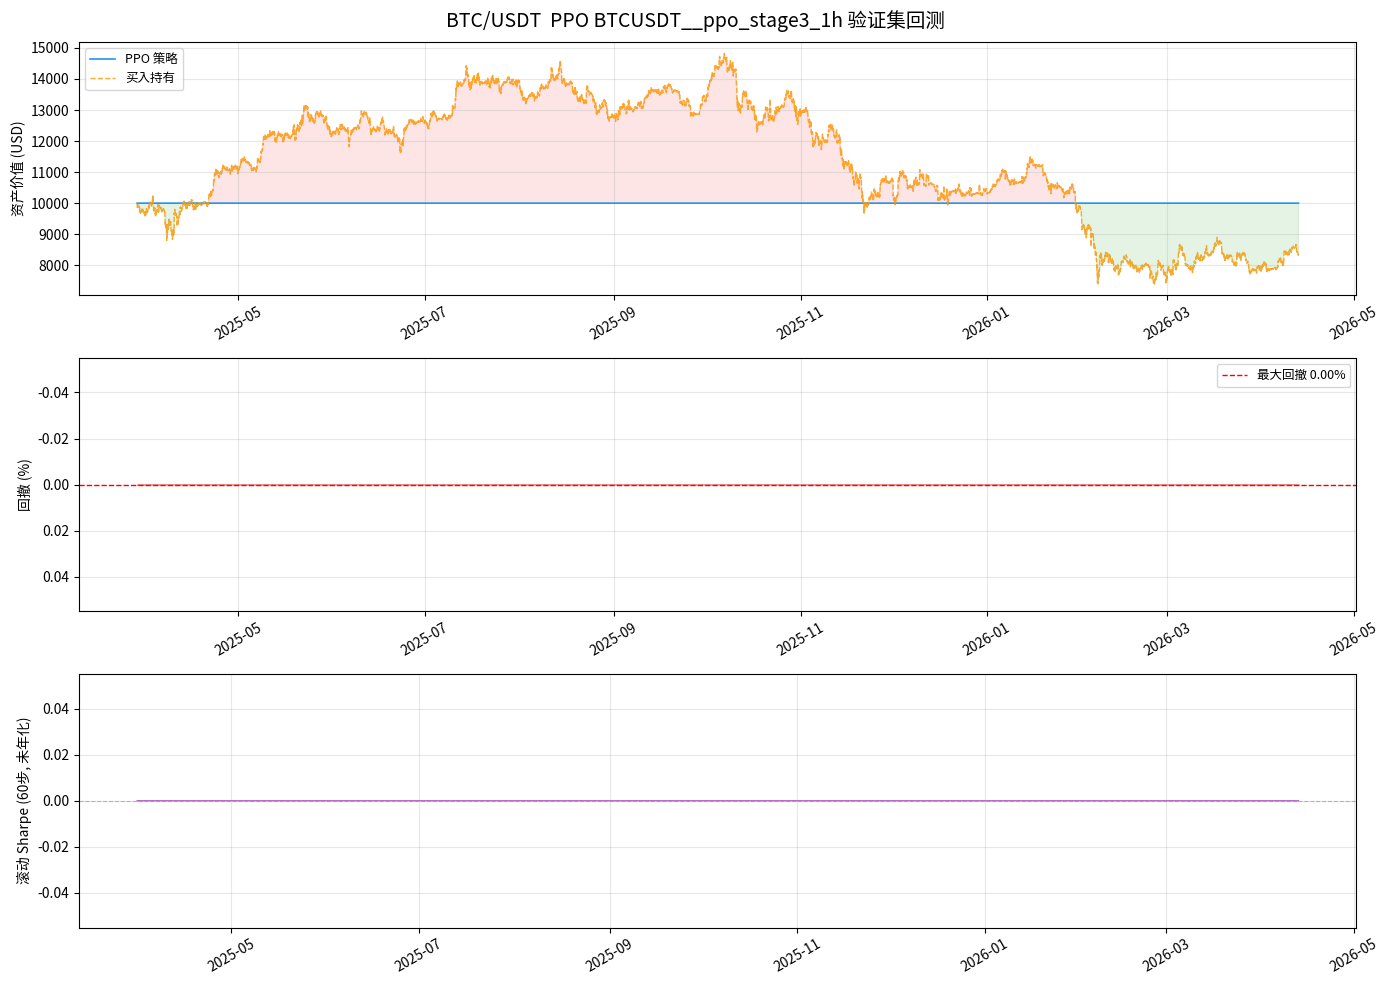

图表已保存: ../models/saved/BTCUSDT__ppo_stage3_1h_backtest.png


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle(f"{SYMBOL}  PPO {RUN_NAME} 验证集回测", fontsize=14)

ts_eval  = eval_ts.iloc[WINDOW_SIZE + 1:].reset_index(drop=True)
bh_curve = INITIAL_BALANCE * (prices_eval / prices_eval[0])

ax0 = axes[0]
ax0.plot(ts_eval, pv_curve, label="PPO 策略", color="#2196f3", linewidth=1.2)
ax0.plot(ts_eval, bh_curve, label="买入持有", color="#ff9800", linewidth=1, linestyle="--", alpha=0.8)
ax0.fill_between(ts_eval, pv_curve, bh_curve, where=pv_curve >= bh_curve, alpha=0.15, color="#4caf50")
ax0.fill_between(ts_eval, pv_curve, bh_curve, where=pv_curve <  bh_curve, alpha=0.15, color="#ef5350")
ax0.set_ylabel("资产价值 (USD)")
ax0.grid(True, alpha=0.3)

buy_idx  = [t["step"] - WINDOW_SIZE for t in trades
            if t["side"] == "buy"  and 0 <= t["step"] - WINDOW_SIZE < len(ts_eval)]
sell_idx = [t["step"] - WINDOW_SIZE for t in trades
            if t["side"] == "sell" and 0 <= t["step"] - WINDOW_SIZE < len(ts_eval)]
if buy_idx:
    ax0.scatter(ts_eval.iloc[buy_idx],  pv_curve[buy_idx],
                color="#4caf50", marker="^", s=40, zorder=5, label="买入")
if sell_idx:
    ax0.scatter(ts_eval.iloc[sell_idx], pv_curve[sell_idx],
                color="#ef5350", marker="v", s=40, zorder=5, label="卖出")
ax0.legend(loc="upper left", fontsize=9)

ax1 = axes[1]
ax1.fill_between(ts_eval, drawdowns * 100, alpha=0.6, color="#ef5350")
ax1.axhline(max_dd * 100, color="red", linestyle="--", linewidth=1,
            label=f"最大回撤 {max_dd:.2%}")
ax1.set_ylabel("回撤 (%)")
ax1.invert_yaxis()
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

roll_w = max(20, min(60, len(step_rets) // 50))
roll_ret    = pd.Series(step_rets)
roll_sharpe = (roll_ret.rolling(roll_w).mean()
               / (roll_ret.rolling(roll_w).std() + 1e-8))
ax2 = axes[2]
ax2.plot(ts_eval.iloc[1:], roll_sharpe, color="#ba68c8", linewidth=1)
ax2.axhline( 0, color="gray",    linestyle="--", linewidth=0.8, alpha=0.5)
ax2.set_ylabel(f"滚动 Sharpe ({roll_w}步, 未年化)")
ax2.grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/{RUN_NAME}_backtest.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"图表已保存: {MODEL_DIR}/{RUN_NAME}_backtest.png")
